# **Preparing the AP-10K Dataset for Animal Pose Estimation**

This notebook performs the preprocessing of the [AP-10K](https://arxiv.org/pdf/2108.12617) dataset, which is specifically designed for animal pose estimation tasks. The main objective is to prepare the data for fine-tuning using the **YOLO-pose** model from [Ultralytics](https://docs.ultralytics.com/tasks/pose/).

The AP-10K dataset consists of 10,015 curated images collected from 23 animal families, covering 54 species (although only 50 are actually present in the annotations) and 17 keypoints per instance. Each image includes high-quality keypoint annotations and may contain one or more animals, making it a robust dataset for complex animal pose estimation scenarios.

The dataset is split into 7,023 training images, 995 validation images, and 1,997 test images, following a 7:1:2 ratio per animal species. Additionally, three different splits are provided for cross-validation, each containing the same number of samples in every set. However, due to computational constraints, only split 1 is used in this case to reduce fine-tuning time.

## **Imports**

In [1]:
# Install Kaleido librarie for visualization with Plotly
!pip install kaleido==0.2.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.5 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.express as px
from google.colab import drive
from tqdm import tqdm
from glob import glob
import yaml
import shutil
import json
import os

In [2]:
# Mount Google Drive in Colab
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


## **Configuration**

In [3]:
raw_data_path = "/content/drive/MyDrive/Datasets/Raw_AP-10K/ap-10k.zip"
data_zip_path = "/content/drive/MyDrive/Datasets/AP-10K.zip"
raw_data_dir = os.path.basename(raw_data_path).split(".")[0]
data_dir = os.path.basename(data_zip_path).split(".")[0]

## **Preprocessing and Saving the Pose Dataset**

The download link is available in the [official AP-10K GitHub repository](https://github.com/AlexTheBad/AP-10K), where the dataset is hosted on Google Drive. To simplify preprocessing in Google Colab, I copied the dataset to my personal Google Drive account.

In [4]:
# Extract the raw dataset
!unzip -q $raw_data_path

In [5]:
# Load COCO-format annotations for the 3 sets (train, validation, and test)
split = 1 # 2 or 3

with open(os.path.join(raw_data_dir, f"annotations/ap10k-train-split{split}.json")) as f:
    train_annotations = json.load(f)

with open(os.path.join(raw_data_dir, f"annotations/ap10k-val-split{split}.json")) as f:
    val_annotations = json.load(f)

with open(os.path.join(raw_data_dir, f"annotations/ap10k-test-split{split}.json")) as f:
    test_annotations = json.load(f)

train_annotations.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [6]:
# View an example and the key lengths of the annotations dictionary
idx = 0

print(len(train_annotations["images"]), train_annotations["images"][idx])
print(len(train_annotations["annotations"]), train_annotations["annotations"][idx])
print(len(train_annotations["categories"]), train_annotations["categories"][0])

7023 {'license': 1, 'id': 371, 'file_name': '000000000371.jpg', 'width': 1024, 'height': 768, 'background': 2}
9122 {'id': 441, 'image_id': 371, 'category_id': 1, 'bbox': [255, 209, 483, 387], 'area': 186921, 'iscrowd': 0, 'num_keypoints': 16, 'keypoints': [0, 0, 0, 681, 464, 2, 687, 527, 2, 612, 380, 2, 312, 257, 2, 501, 401, 2, 516, 467, 2, 528, 542, 2, 570, 401, 2, 627, 449, 2, 612, 539, 2, 321, 362, 2, 276, 404, 2, 282, 548, 2, 357, 374, 2, 321, 428, 2, 348, 563, 2]}
54 {'id': 1, 'name': 'antelope', 'supercategory': 'Bovidae', 'keypoints': ['left_eye', 'right_eye', 'nose', 'neck', 'root_of_tail', 'left_shoulder', 'left_elbow', 'left_front_paw', 'right_shoulder', 'right_elbow', 'right_front_paw', 'left_hip', 'left_knee', 'left_back_paw', 'right_hip', 'right_knee', 'right_back_paw'], 'skeleton': [[1, 2], [1, 3], [2, 3], [3, 4], [4, 5], [4, 6], [6, 7], [7, 8], [4, 9], [9, 10], [10, 11], [5, 12], [12, 13], [13, 14], [5, 15], [15, 16], [16, 17]]}


In [7]:
def parse_coco_annotations(annotations):
    """
    Parses COCO-style annotations into a structured DataFrame containing filenames,
    keypoints, bounding boxes, number of keypoints, and animal species.

    Args:
        annotations (dict): Dictionary of annotations in COCO format.

    Returns:
        (pd.DataFrame): DataFrame with one row per image, including aggregated pose data.
    """

    # Merge image metadata with annotation entries (based on image ID)
    df = pd.merge(
        left=pd.DataFrame(annotations["images"], columns=["id", "file_name"]),
        right=pd.DataFrame(annotations["annotations"], columns=["image_id", "keypoints", "num_keypoints", "bbox", "category_id"]),
        how="inner",
        left_on="id",
        right_on="image_id"
    )

    # Merge with category information (species names)
    df = pd.merge(
        left=df,
        right=pd.DataFrame(annotations["categories"], columns=["name", "id"]),
        how="inner",
        left_on="category_id",
        right_on="id"
    )

    # Drop redundant columns and group by image
    df = df.drop(columns=["id_x", "image_id", "category_id", "id_y"])
    df = df.groupby("file_name", as_index=False).agg({"keypoints": list, "num_keypoints": list, "bbox": list, "name": list})

    # Rename column 'name' to 'specie'
    df = df.rename(columns={"name": "specie"})

    return df.reset_index(drop=True)

In [8]:
df_train = parse_coco_annotations(train_annotations)
df_val = parse_coco_annotations(val_annotations)
df_test = parse_coco_annotations(test_annotations)

df_train

,file_name,keypoints,num_keypoints,bbox,specie
0,000000000001.jpg,"[[76, 373, 2, 46, 378, 2, 88, 403, 2, 13, 433,...","[4, 17, 4]","[[3, 303, 100, 180], [256, 98, 400, 452], [418...","[antelope, antelope, antelope]"
1,000000000002.jpg,"[[546, 224, 2, 450, 218, 2, 501, 314, 2, 471, ...",[14],"[[249, 31, 733, 679]]",[antelope]
2,000000000004.jpg,"[[488, 443, 2, 0, 0, 0, 466, 499, 2, 600, 307,...",[16],"[[408, 197, 429, 341]]",[antelope]
3,000000000034.jpg,"[[432, 227, 2, 390, 227, 2, 384, 284, 2, 483, ...",[17],"[[321, 23, 399, 653]]",[antelope]
4,000000000037.jpg,"[[161, 336, 2, 148, 336, 2, 157, 354, 2, 155, ...","[13, 10, 17, 17, 15, 16, 16, 14]","[[126, 306, 57, 165], [197, 178, 133, 142], [2...","[antelope, antelope, antelope, antelope, antel..."
...,...,...,...,...,...
7018,000000058621.jpg,"[[473, 425, 2, 379, 422, 2, 426, 462, 2, 389, ...",[14],"[[74, 306, 464, 556]]",[polar bear]
7019,000000058622.jpg,"[[593, 246, 2, 540, 238, 2, 535, 288, 2, 720, ...",[11],"[[428, 142, 578, 465]]",[polar bear]
7020,000000058623.jpg,"[[397, 506, 2, 385, 498, 2, 374, 518, 2, 457, ...",[14],"[[370, 429, 246, 183]]",[polar bear]
7021,000000058624.jpg,"[[285, 253, 2, 215, 243, 2, 208, 313, 2, 488, ...",[13],"[[174, 62, 827, 612]]",[polar bear]


In [9]:
print(df_train.info(), "\n")
print(df_val.info(), "\n")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7023 entries, 0 to 7022
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file_name      7023 non-null   object
 1   keypoints      7023 non-null   object
 2   num_keypoints  7023 non-null   object
 3   bbox           7023 non-null   object
 4   specie         7023 non-null   object
dtypes: object(5)
memory usage: 274.5+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file_name      995 non-null    object
 1   keypoints      995 non-null    object
 2   num_keypoints  995 non-null    object
 3   bbox           995 non-null    object
 4   specie         995 non-null    object
dtypes: object(5)
memory usage: 39.0+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (tot

In [12]:
def count_column_instances(df, column, set_name="train"):
    """
    Counts the number of occurrences for each unique value in a specified column.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        column (str): Name of the column to count values from.
        set_name (str): Name of the dataset split: "train", "val" or "test".

    Returns:
        (pd.DataFrame): A DataFrame with columns [column, "count", "set"].
    """
    # Flatten the list of values in the column and count occurrences
    count = np.unique(sum(df[column].values.tolist(), []), return_counts=True)
    return pd.DataFrame({column: count[0], "count": count[1], "set": set_name})


def plot_column_distribution(column, ascending=False, renderer=None):
    """
    Plots a stacked bar chart showing the distribution of values for a given column
    across the train, validation, and test sets.

    Args:
        column (str): Column name to visualize (e.g., 'specie', 'num_keypoints').
        ascending (bool): Whether to sort the bars in ascending order.
        renderer (str): Optional Plotly renderer (e.g., 'png', 'notebook').
    """
    # Count instances across all dataset splits
    df_count = pd.concat([
        count_column_instances(df_train, column),
        count_column_instances(df_test, column, "test"),
        count_column_instances(df_val, column, "val")
    ])

    # Ensure column is treated as string (categorical column)
    df_count[column] = df_count[column].astype(str)

    # Compute total frequency per unique value for sorting
    total_counts = df_count.groupby(column)["count"].sum().sort_values(ascending=ascending)

    # Create the stacked bar plot
    fig = px.bar(
        df_count,
        x=column,
        y="count",
        color="set",
        barmode="stack",
        title=f"{' '.join([w.capitalize() for w in column.split('_')])} Frequency Across Sets",
        category_orders={column: total_counts.index.tolist()}
    )
    fig.update_layout(
        title_font=dict(size=16),
        xaxis_tickangle=-90,
        title_x=0.5,
        width=1200,
        height=600
    )

    fig.show(renderer=renderer)

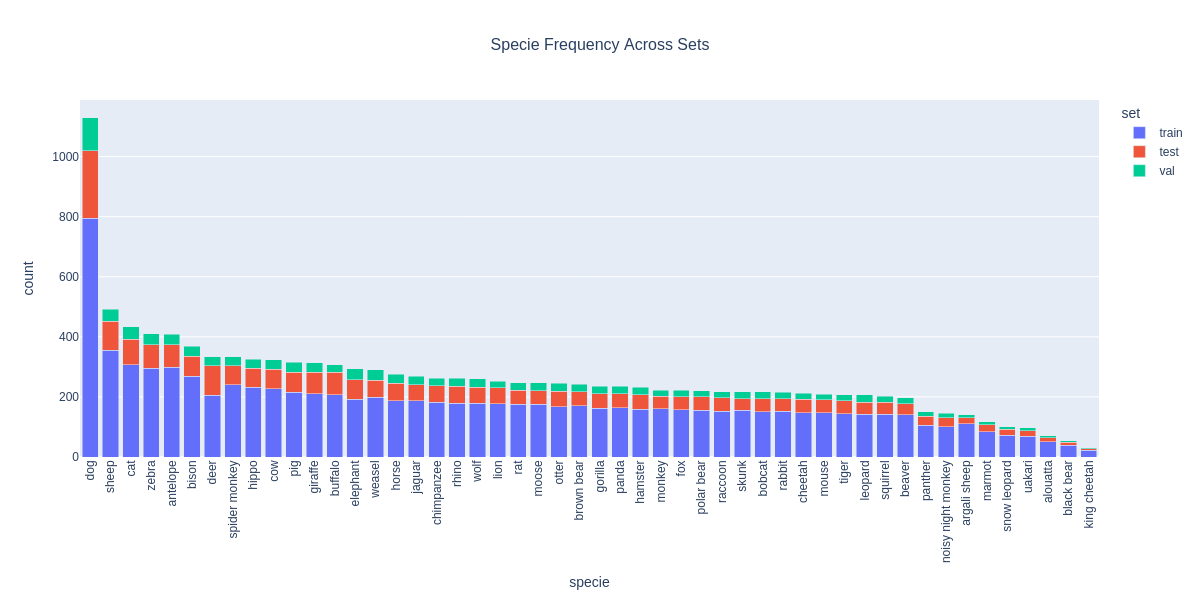

In [13]:
plot_column_distribution("specie")
plot_column_distribution("specie", renderer="png")

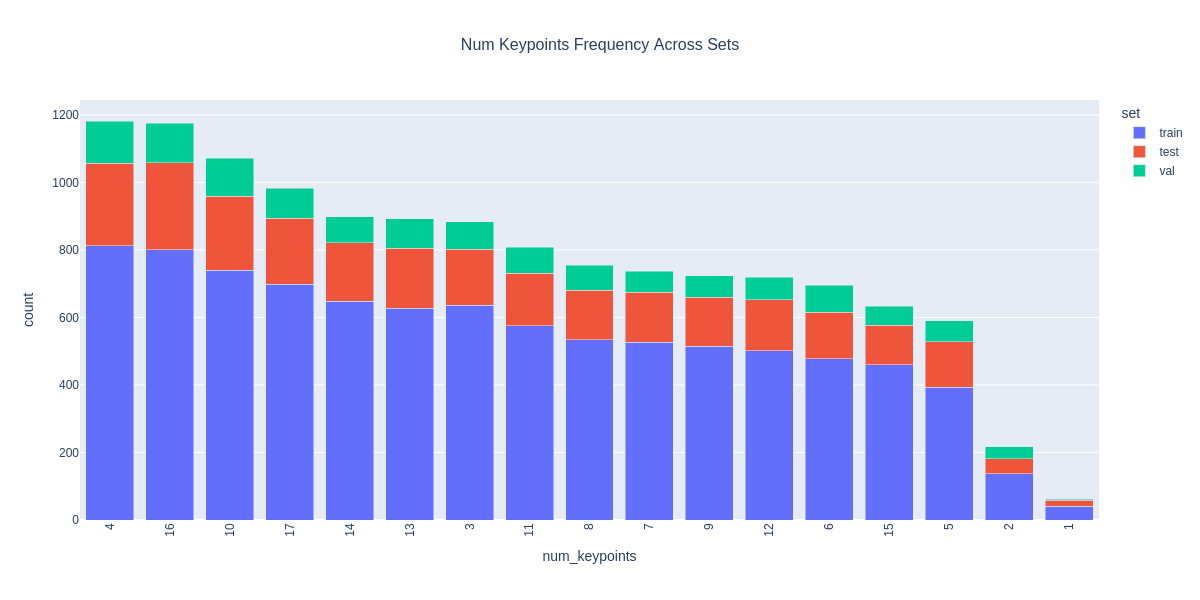

In [14]:
plot_column_distribution("num_keypoints")
plot_column_distribution("num_keypoints", renderer="png")

The species barplot shows that the distribution of species is consistent across the three dataset splits (train, validation, and test), which aligns with the official paper's description: the number of instances per species follows a 7:1:2 ratio. This setup is robust for evaluating model performance when fine-tuning with AP-10K.

However, there is a significant class imbalance. The most represented species are **dog**, **sheep**, and **cat**, while the least represented include **alouatta**, **black bear**, and **king cheetah**. This creates a major challenge for multi-class pose estimation, not only due to the imbalance and the large number of classes (50), but also because many species from the same family are morphologically similar making this a potential *fine-grained animal pose estimation* task.

The current preprocessing pipeline supports both multi-class and single-class animal pose estimation. The latter is the approach used in the original paper, and it is conceptually simpler, as the model focuses solely on detecting animals and predicting keypoints, regardless of species. In that case, the class imbalance has little impact on performance.

In my project, this preprocessed dataset will be used for multi-class animal pose estimation, which will present a challenging task to put **YOLO11-pose** to the test.

In [15]:
# Create class dictionaries and compute the total number of keypoints
id2class = count_column_instances(df_train, "specie").specie.to_dict()
class2id = {v: k for k, v in id2class.items()}
nkpts = len(count_column_instances(df_train, "num_keypoints"))

print(f"Number of keypoints: {nkpts}\nNumber of classes: {len(id2class)}\n")
id2class

Number of keypoints: 17
Number of classes: 50



{0: 'alouatta',
 1: 'antelope',
 2: 'argali sheep',
 3: 'beaver',
 4: 'bison',
 5: 'black bear',
 6: 'bobcat',
 7: 'brown bear',
 8: 'buffalo',
 9: 'cat',
 10: 'cheetah',
 11: 'chimpanzee',
 12: 'cow',
 13: 'deer',
 14: 'dog',
 15: 'elephant',
 16: 'fox',
 17: 'giraffe',
 18: 'gorilla',
 19: 'hamster',
 20: 'hippo',
 21: 'horse',
 22: 'jaguar',
 23: 'king cheetah',
 24: 'leopard',
 25: 'lion',
 26: 'marmot',
 27: 'monkey',
 28: 'moose',
 29: 'mouse',
 30: 'noisy night monkey',
 31: 'otter',
 32: 'panda',
 33: 'panther',
 34: 'pig',
 35: 'polar bear',
 36: 'rabbit',
 37: 'raccoon',
 38: 'rat',
 39: 'rhino',
 40: 'sheep',
 41: 'skunk',
 42: 'snow leopard',
 43: 'spider monkey',
 44: 'squirrel',
 45: 'tiger',
 46: 'uakari',
 47: 'weasel',
 48: 'wolf',
 49: 'zebra'}

In the **AP-10K** dataset, keypoints only take two values: **0** (not annotated) and **2** (visible and annotated), unlike the **COCO** dataset, which uses three values: **0** (not annotated), **1** (annotated but not visible), and **2** (annotated and visible).

Unlike other pose estimation models that typically follow a two-stage approach, **YOLO-pose** operates in a single stage. This is similar to a bottom-up approach but without the need to generate heatmaps, meaning keypoint coordinates do not need to be integers.

For pose estimation, **Ultralytics** expects each row of the label file corresponding to an image to follow the [format](https://docs.ultralytics.com/datasets/pose/):

```
<class_id> <x_center> <y_center> <width> <height> <x1> <y1> <v1> ... <xn> <yn> <vn>
```

Where:

* **x_center** and **y_center** are the coordinates of the object’s bounding box center, normalized by the image width and height.
* **width** and **height** are the normalized width and height of the bounding box.
* **x1, y1, v1, ..., xn, yn, vn** are the keypoint coordinates normalized by the image dimensions.

It is important to note that the pose estimation metrics used by Ultralytics are based on the [Object Keypoint Similarity (OKS)](https://cocodataset.org/#keypoints-eval) metric. In this case, the segmented area of the object is not required, as it is heuristically estimated to be approximately 53% of the object's bounding box area, as indicated in the [Ultralytics documentation](https://github.com/ultralytics/ultralytics/blob/35a4b17d9bd549e77d6b65f86c0f844288cbb1ac/ultralytics/models/yolo/pose/val.py#L197).

In [16]:
# Identify species that are not present in all three sets
for name in [dic["name"] for dic in train_annotations["categories"]]:
    if name not in id2class.values():
        print(name)

arctic fox
orangutan
mole
bat


In [17]:
# Ensure that keypoint visibility values are only 0 or 2
for _, row in tqdm(pd.concat([df_train, df_val, df_test]).iterrows()):
   for kpts in row["keypoints"]:
    kpts = np.array(kpts).reshape(-1, 3)
    if np.any(kpts[:, 2] == 1):
        print(kpts)

10015it [00:00, 13568.45it/s]


In [18]:
def preprocess_and_save(raw_data_dir, data_dir, df, class2id, split="train"):
    """
    Preprocesses and saves dataset annotations in Ultralytics YOLO format for pose estimation.

    Args:
        raw_data_dir (str): Path to the raw dataset containing images and annotations.
        data_dir (str): Path where the processed dataset will be saved.
        df (pd.DataFrame): DataFrame containing image filenames, keypoints, bounding boxes, and class names.
        class2id (dict[str, int]): Dictionary mapping class names to integer class IDs.
        split (str, optional): Dataset split name: 'train', 'val', or 'test'.
    """
    if split not in {"train", "val", "test"}:
        raise ValueError("Invalid dataset split. Choose either 'train', 'val' or 'test'.")

    # Create directories for processed images and labels
    images_dir = os.path.join(data_dir, split, "images")
    labels_dir = os.path.join(data_dir, split, "labels")
    os.makedirs(data_dir, exist_ok=True)
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    for _, row in tqdm(df.iterrows(), total=len(df)):
        # Extract image filename and dimensions
        filename = row["file_name"]
        img_path = os.path.join(raw_data_dir, "data", filename)
        width, height = Image.open(img_path).size

        labels = []
        invalid_file = False

        for kpts, bbox, specie in zip(row["keypoints"], row["bbox"], row["specie"]):
            # Extract and validate bounding box coordinates
            xmin, ymin, w, h = bbox
            xmax, ymax = xmin + w, ymin + h
            if (xmin < 0) or (ymin < 0) or (xmax > width) or (ymax > height):
                print(f"File {filename} is corrupted: bounding box exceeds image dimensions.")
                invalid_file = True
                break

            # Extract and validate keypoints
            kpts = np.array(kpts, dtype=np.float32).reshape(-1, 3)
            mask = (kpts[:, 2] > 0) & (
                (kpts[:, 0] > xmax) | (kpts[:, 1] > ymax) |
                (kpts[:, 0] < xmin) | (kpts[:, 1] < ymin)
            )
            if np.any(mask):
                print(f"File {filename} is corrupted: keypoints fall outside the bounding box.")
                invalid_file = True
                break

            # Get class ID
            cls = class2id[specie]

            # Normalize bounding box to YOLO format
            x_center = (xmin + (w / 2)) / width
            y_center = (ymin + (h / 2)) / height
            w /= width
            h /= height

            # Normalize keypoint coordinates
            kpts[:, 0] /= width
            kpts[:, 1] /= height

            # Construct label in YOLO keypoint format
            label = [cls, x_center, y_center, w, h] + kpts.flatten().tolist()
            labels.append(label)

        # Skip files with invalid annotations
        if invalid_file:
            continue

        # Save labels file
        with open(os.path.join(labels_dir, filename.split(".jpg")[0] + ".txt"), "w") as f:
            f.writelines(" ".join(map(str, row)) + "\n" for row in labels)

        # Copy image to images directory
        shutil.copy(img_path, os.path.join(images_dir, filename))

In [19]:
preprocess_and_save(raw_data_dir, data_dir, df_train, class2id)
preprocess_and_save(raw_data_dir, data_dir, df_val, class2id, split="val")
preprocess_and_save(raw_data_dir, data_dir, df_test, class2id, split="test")

100%|██████████| 1997/1997 [00:08<00:00, 222.26it/s]


In pose estimation, it's also important to know the name of each keypoint, its ID, and the ID of the keypoint it connects to. This information is essential for understanding the dataset structure and accurately visualizing keypoints during inference.

To achieve this, a dictionary called **skeleton** is created, where each key corresponds to a keypoint name, and each value is another dictionary containing two elements: a list of two IDs (the first is the keypoint's ID, and the second is the ID of the connected keypoint) and the RGB color assigned to that keypoint. It is worth noting that the colors used match those from the official AP-10K GitHub repository and paper.

A list called **flip_idx** is also required. It contains the IDs of symmetric keypoints that are swapped during horizontal flipping, while leaving non-symmetric ones unchanged. This list is crucial for applying random horizontal flipping as part of Ultralytics' data augmentation pipeline.

With all this information along with the image and label paths and the class dictionary the metadata for the AP-10K dataset is generated and saved in YAML files for both training and evaluation using the validation and test sets.


In [20]:
train_annotations["categories"][0]["keypoints"]

['left_eye',
 'right_eye',
 'nose',
 'neck',
 'root_of_tail',
 'left_shoulder',
 'left_elbow',
 'left_front_paw',
 'right_shoulder',
 'right_elbow',
 'right_front_paw',
 'left_hip',
 'left_knee',
 'left_back_paw',
 'right_hip',
 'right_knee',
 'right_back_paw']

In [21]:
skeleton = {
    "left_eye": {"ids": [0, 1], "color": [255, 0, 0]},
    "right_eye": {"ids": [1, 2], "color": [255, 0, 0]},
    "nose": {"ids": [2, 0], "color": [255, 0, 0]},
    "neck": {"ids": [3, 2], "color": [0, 255, 0]},
    "root_of_tail": {"ids": [4, 3], "color": [0, 255, 0]},
    "left_shoulder": {"ids": [5, 3], "color": [255, 255, 0]},
    "left_elbow": {"ids": [6, 5], "color": [255, 255, 0]},
    "left_front_paw": {"ids": [7, 6], "color": [255, 255, 0]},
    "right_shoulder": {"ids": [8, 3], "color": [255, 128, 0]},
    "right_elbow": {"ids": [9, 8], "color": [255, 128, 0]},
    "right_front_paw": {"ids": [10, 9], "color": [255, 128, 0]},
    "left_hip": {"ids": [11, 4], "color": [255, 255, 0]},
    "left_knee": {"ids": [12, 11], "color": [255, 255, 0]},
    "left_back_paw": {"ids": [13, 12], "color": [255, 255, 0]},
    "right_hip": {"ids": [14, 4], "color": [255, 128, 0]},
    "right_knee": {"ids": [15, 14], "color": [255, 128, 0]},
    "right_back_paw": {"ids": [16, 15], "color": [255, 128, 0]}
}

symmetric_kpts = [[0, 1], [5, 8], [6, 9], [7, 10], [11, 14], [12, 15], [13, 16]]
flip_idx = np.arange(nkpts)
for pair in symmetric_kpts:
    flip_idx[pair] = flip_idx[pair[::-1]]

flip_idx

array([ 1,  0,  2,  3,  4,  8,  9, 10,  5,  6,  7, 14, 15, 16, 11, 12, 13])

In [22]:
# Create and save the YAML files with the dataset metadata
metadata = {
    "path": f"../{data_dir}",
    "train": "train/images",
    "val": "val/images",

    "skeleton": skeleton,
    "kpt_shape": [nkpts, 3],
    "flip_idx": flip_idx.tolist(),

    "names": id2class,
}

with open(os.path.join(data_dir, f"val_data.yaml"), "w") as f:
  yaml.dump(metadata, f, default_flow_style=False, sort_keys=False)

metadata["val"] = "test/images"
with open(os.path.join(data_dir, f"test_data.yaml"), "w") as f:
  yaml.dump(metadata, f, default_flow_style=False, sort_keys=False)

In [23]:
!du -sh $data_dir

3.3G	AP-10K


In [ ]:
# Compress and save the preprocessed pose dataset in ZIP format
!zip -r $data_zip_path {data_dir} -q

## **Visualization Example**

In [ ]:
class PoseVisualizer():
    """
    Visualizes pose keypoints, skeletons, bounding boxes, and class labels from YOLO-format annotations.

    Args:
        skeleton (dict[str, dict]): Dictionary where each key is a keypoint name, and its value is a dict with:
            - ids: list of two integers indicating the keypoint pair for a skeleton edge.
            - color: RGB list for drawing the edge/keypoint.
        id2class (dict[int, str]): Mapping from class IDs to class names.
    """

    def __init__(self, skeleton, id2class):
        self.skeleton = skeleton
        self.id2class = id2class

    def draw_keypoints(self, ax, keypoints, show_kpts=True, show_lines=True, show_kpts_ids=True):
        """
        Draws keypoints and connecting skeleton lines on a given Matplotlib Axes.

        Args:
            ax (plt.Axes): Matplotlib Axes to draw on.
            keypoints (np.ndarray): Array of shape (nkpts, 3), with (x, y, visibility).
            show_kpts (bool): Whether to draw keypoint circles.
            show_lines (bool): Whether to draw lines between keypoint pairs.
            show_kpts_ids (bool): Whether to label keypoints with their index.
        """
        for dic in self.skeleton.values():
            ids = dic["ids"]
            color = np.array(dic["color"]) / 255

            # Draw connecting line only if both keypoints are visible
            if show_lines and np.all(keypoints[ids, 2] > 0):
                ax.plot(
                    keypoints[ids, 0],
                    keypoints[ids, 1],
                    color=color,
                    linewidth=2 if show_kpts_ids else 1.75,
                    zorder=1
                )

            # Draw individual keypoint if visible
            id = ids[0]
            x, y, v = keypoints[id]
            if v > 0:
                # Draw keypoint as a circle
                if show_kpts:
                    ax.scatter(
                        x, y,
                        color=color,
                        s=(50 if id > 9 else 40) if show_kpts_ids else 30,
                        zorder=2
                    )

                # Display keypoint ID as label
                if show_kpts_ids:
                    ax.text(
                        x, y, str(id),
                        fontsize=5, fontweight="bold",
                        ha="center", va="center", zorder=3
                    )

    def visualize(
        self, image_paths, label_paths, n_rows=2, n_cols=1, random=True,
        show_kpts=True, show_lines=True, show_kpts_ids=True,
        show_boxes=True, show_labels=True,
    ):
        """
        Displays a grid of images with overlaid pose annotations.

        Args:
            image_paths (list[str]): Paths to images.
            label_paths (list[str]): Corresponding YOLO-format label file paths.
            n_rows (int): Number of rows in the grid.
            n_cols (int): Number of columns in the grid.
            random (bool): Whether to shuffle images.
            show_kpts (bool): Whether to display keypoint markers.
            show_lines (bool): Whether to display skeleton lines.
            show_kpts_ids (bool): Whether to label keypoints with their index.
            show_boxes (bool): Whether to draw bounding boxes.
            show_labels (bool): Whether to show class labels.
        """
        indices = np.arange(len(image_paths))
        if random:
            np.random.shuffle(indices)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(9.6 * n_cols, 4.8 * n_rows))
        axes = axes.flatten() if (n_rows * n_cols) > 1 else [axes]

        for i, ax in enumerate(axes):
            idx = indices[i]

            # Load and show image
            image = np.array(Image.open(image_paths[idx]).convert("RGB"))
            height, width = image.shape[:2]
            ax.imshow(image)
            ax.axis("off")

            # Read labels file
            labels = np.loadtxt(label_paths[idx], np.float32, ndmin=2)

            for label in labels:
                # Extract, denormalize and draw keypoints coordinates
                kpts = label[5:].reshape(-1, 3)
                kpts[:, 0] *= width
                kpts[:, 1] *= height
                self.draw_keypoints(ax, kpts, show_kpts=show_kpts, show_lines=show_lines, show_kpts_ids=show_kpts_ids)

                if show_boxes:
                    # Extract, denormalize and draw bbox coordinates
                    x_center, y_center, w, h = label[1:5]
                    xmin = (x_center - (w / 2)) * width
                    ymin = (y_center - (h / 2)) * height
                    w *= width
                    h *= height
                    rect = patches.Rectangle((xmin, ymin), w, h, linewidth=1.75, edgecolor="blue", facecolor="none")
                    ax.add_patch(rect)

                    # Add class label
                    if show_labels:
                        label = self.id2class[int(label[0])]
                        text = ax.text(
                            xmin, ymin, label,
                            color="white", fontsize=10, fontweight="semibold",
                            ha="left", va="top" if ymin < (0.05 * height) else "bottom",
                            bbox={"boxstyle": "square,pad=0", "facecolor": "blue", "edgecolor": "blue", "alpha": 1.0}
                        )

        plt.tight_layout()
        plt.show()

In [49]:
visualizer = PoseVisualizer(skeleton, id2class)

In [31]:
# Retrieve the file paths for training images and labels
split = "train"
image_paths = np.sort(glob(os.path.join(data_dir, f"{split}/images/*.jpg")))
label_paths = np.sort(glob(os.path.join(data_dir, f"{split}/labels/*.txt")))

len(image_paths), len(label_paths)

(7023, 7023)

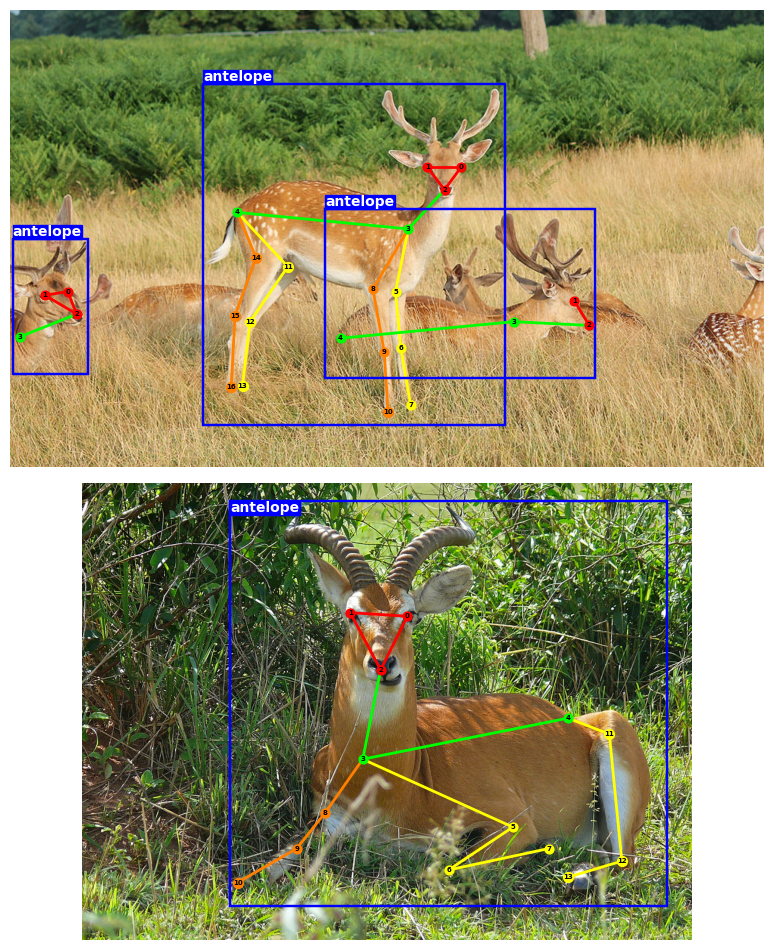

In [50]:
visualizer.visualize(image_paths, label_paths, random=False)

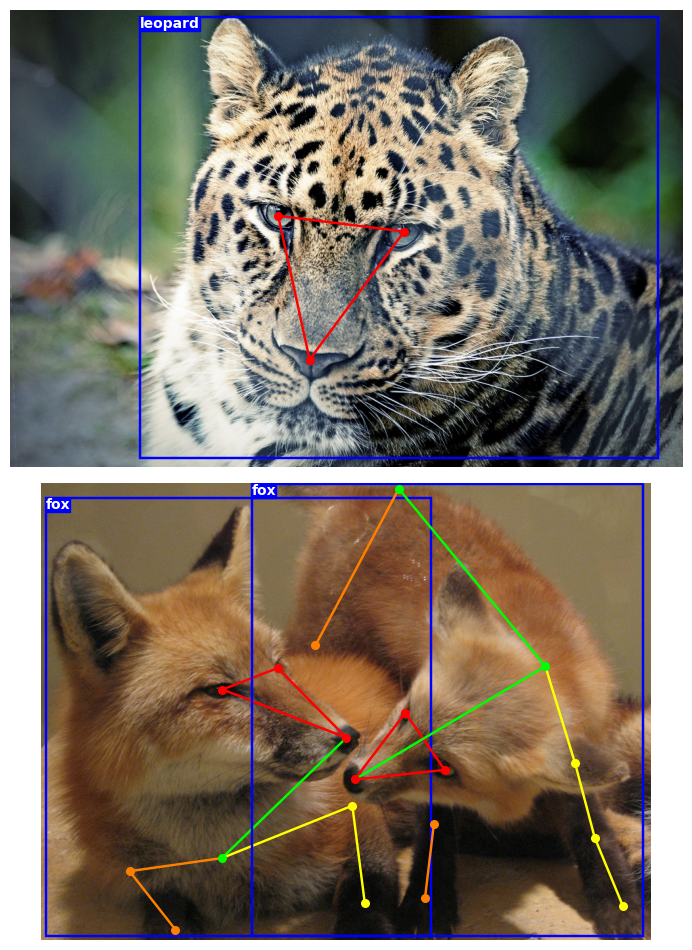

In [68]:
visualizer.visualize(image_paths, label_paths, show_kpts_ids=False)

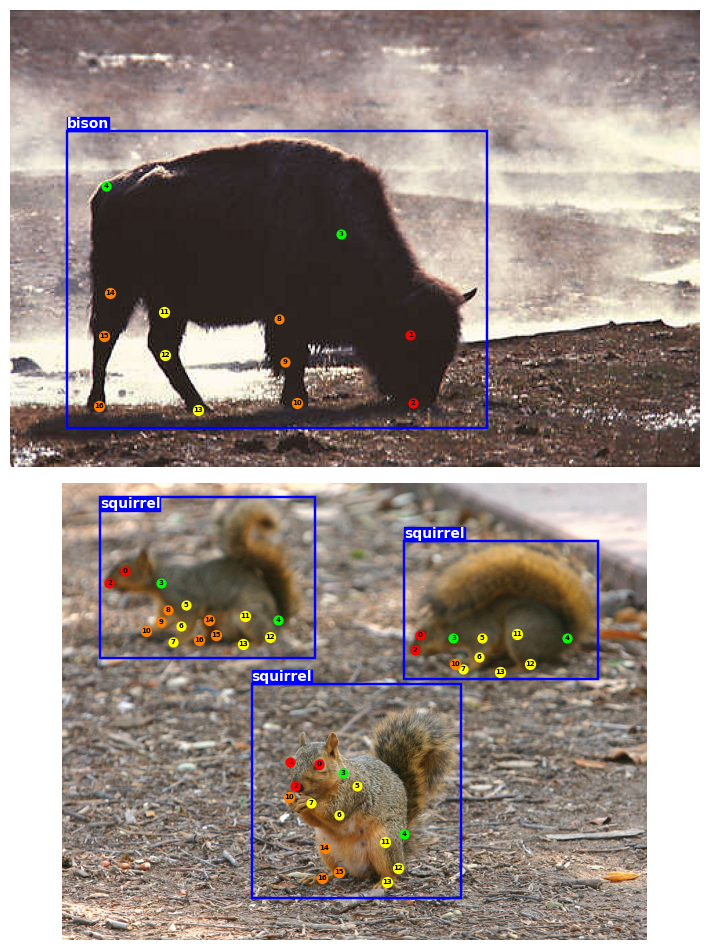

In [92]:
visualizer.visualize(image_paths, label_paths, show_lines=False)